# Modular SAXS/WAXS Analysis Pipeline
This notebook runs the analysis using modular functions and settings from `sample_settings.csv`.

In [1]:
%load_ext autoreload
%autoreload 2
#%matplotlib widget
import sys
import os
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
# Add root directory to python path for imports
sys.path.append('..')

from classes_and_functions.read_data import DataReader, read_background_directory, read_background_file
from classes_and_functions.electrochemical_data_filtration import process_electrochemical_data
from classes_and_functions.data_correction import DataCorrection
from classes_and_functions.utils import contourplot, subtract_background, combined_contourplot, plot_3d_waterfall, plot_2d_waterfall, plot_selected_curves
from classes_and_functions.fitting import fit_waxs_peaks, interactive_fit_viewer, plot_peak_areas, calculate_saxs_invariants, plot_combined_saxs_waxs_ec, plot_saxs_invariants

## 1. Load Settings and Select Sample

In [2]:
import ipywidgets as widgets
from IPython.display import display
import pandas as pd

# Create form to add new sample
style = {'description_width': 'initial'}
sample_id_input = widgets.Text(description="Sample ID:", style=style)
data_format_input = widgets.Dropdown(options=["Individual", "HDF5"], description="Data Format:", style=style)
data_path_input = widgets.Text(description="Data Path (Folder or .h5 file):", style=style)
mpr_path_input = widgets.Text(description="MPR File Path (if Individual):", style=style)
empty_saxs_input = widgets.Text(description="Empty Cell SAXS Dir (Optional):", style=style)
empty_waxs_input = widgets.Text(description="Empty Cell WAXS Dir (Optional):", style=style)
discharge_rate_input = widgets.FloatText(value=10.0, description="Discharge Rate:", style=style)

save_button = widgets.Button(description="Save Sample", button_style='success')
output = widgets.Output()

import os

def get_rel_path(p):
    if not p:
        return p
    p = str(p).strip()
    try:
        repo_root = os.path.abspath('..')
        if os.path.isabs(p):
            return os.path.relpath(p, repo_root).replace('\\', '/')
        return p.replace('\\', '/')
    except Exception:
        return p.replace('\\', '/')

def save_sample(b):
    with output:
        output.clear_output()
        if not sample_id_input.value or not data_path_input.value:
            print("Please provide Sample ID and Data Path.")
            return
            
        csv_path = 'sample_settings.csv'
        try:
            df = pd.read_csv(csv_path)
        except FileNotFoundError:
            df = pd.DataFrame(columns=['Sample_ID', 'Data_Format', 'Data_Path', 'MPR_File_Path', 
                                       'Discharge_Rate', 'SAXS_Min_Limit', 'SAXS_Max_Limit', 
                                       'WAXS_Min_Limit', 'WAXS_Max_Limit', 'Empty_Dir_SAXS', 
                                       'Empty_Dir_WAXS', 'Capillary_SAXS', 'Capillary_WAXS'])
        
        if sample_id_input.value in df['Sample_ID'].values:
            print(f"Sample '{sample_id_input.value}' already exists! Update manually or use a new ID.")
            return
            
        new_row = {
            'Sample_ID': sample_id_input.value,
            'Data_Format': data_format_input.value,
            'Data_Path': get_rel_path(data_path_input.value),
            'MPR_File_Path': get_rel_path(mpr_path_input.value) if mpr_path_input.value else None,
            'Discharge_Rate': discharge_rate_input.value,
            'SAXS_Min_Limit': 0.13,  # default
            'SAXS_Max_Limit': 3.0,   # default
            'WAXS_Min_Limit': 22.0,  # default
            'WAXS_Max_Limit': 30.0,  # default
            'Empty_Dir_SAXS': get_rel_path(empty_saxs_input.value) if empty_saxs_input.value else None,
            'Empty_Dir_WAXS': get_rel_path(empty_waxs_input.value) if empty_waxs_input.value else None,
            'Capillary_SAXS': None,
            'Capillary_WAXS': None
        }
        
        df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
        df.to_csv(csv_path, index=False)
        print(f"Successfully added sample: {sample_id_input.value}! Please re-run the dropdown cell below to see it.")

save_button.on_click(save_sample)

form = widgets.VBox([
    widgets.HTML("<h3>Add New Sample to Settings</h3>"),
    sample_id_input, 
    data_format_input, 
    data_path_input, 
    mpr_path_input,
    empty_saxs_input,
    empty_waxs_input,
    discharge_rate_input,
    save_button,
    output
])
display(form)


In [3]:
settings_df = pd.read_csv('sample_settings.csv')
sample_selector = widgets.Dropdown(
    options=settings_df['Sample_ID'].tolist(),
    description='Sample:',
)
display(sample_selector)

Dropdown(description='Sample:', options=('Without_iodine_20251017', 'HDF5_Test_Sample', 'S-Operando-7', 'SPSE-…

In [4]:
# Get settings for selected sample
sample_settings = settings_df[settings_df['Sample_ID'] == sample_selector.value].iloc[0]
print(f"Selected Sample: {sample_settings['Sample_ID']}")
print(f"Data Format: {sample_settings['Data_Format']}")

Selected Sample: SI20-Operando-06
Data Format: HDF5


## 2. Read Data

In [5]:
reader = DataReader(
    data_format=sample_settings['Data_Format'],
    data_path=sample_settings['Data_Path'],
    mpr_file_path=sample_settings.get('MPR_File_Path') if pd.notna(sample_settings.get('MPR_File_Path')) else None
)
all_data = reader.read_data()
print(f"Loaded {len(all_data['SAXS'])} SAXS files and {len(all_data['WAXS'])} WAXS files.")

if all_data.get('Electrochemical') is not None:
    print(f"Found Electrochemical data: {len(all_data['Electrochemical'])} rows.")
else:
    print("No Electrochemical data found.")

if all_data.get('Background_SAXS') is not None:
    print("Found SAXS Background data.")
else:
    print("No SAXS Background data found.")
    
if all_data.get('Background_WAXS') is not None:
    print("Found WAXS Background data.")
else:
    print("No WAXS Background data found.")


Loaded 429 SAXS files and 429 WAXS files.
Found Electrochemical data: 35796 rows.
Found SAXS Background data.
Found WAXS Background data.


## 3. Data Correction (Background)

In [6]:
# Load Backgrounds into all_data (if using INDIVIDUAL files)
if sample_settings['Data_Format'].lower() == 'individual':
    if pd.notna(sample_settings.get('Empty_Dir_SAXS')):
        empty_saxs_dict = read_background_directory(sample_settings['Empty_Dir_SAXS'], '*_0_*.dat')
        if empty_saxs_dict and len(empty_saxs_dict) > 0:
            all_data['Background_SAXS'] = list(empty_saxs_dict.values())[0]
            print(f"Loaded SAXS background from {sample_settings['Empty_Dir_SAXS']}")
            
    if pd.notna(sample_settings.get('Empty_Dir_WAXS')):
        empty_waxs_dict = read_background_directory(sample_settings['Empty_Dir_WAXS'], '*_1_*.dat')
        if empty_waxs_dict and len(empty_waxs_dict) > 0:
            all_data['Background_WAXS'] = list(empty_waxs_dict.values())[0]
            print(f"Loaded WAXS background from {sample_settings['Empty_Dir_WAXS']}")
else:
    print("Backgrounds already loaded from HDF5.")

Backgrounds already loaded from HDF5.


## 4. Process Electrochemical Data

Indices for cycle change: [961, 9603, 16053, 22602, 29112, 35602, 35795]

Absolute times for change in electrochemical state:
[np.float64(960.00037574835), np.float64(44160.000770608254), np.float64(76396.61604140361), np.float64(109129.94909864245), np.float64(141666.99136615638), np.float64(174252.52346454468), np.float64(175214.5402150643)]
Corresponding SAXS file numbers:
[3, 113, 195, 278, 361, 429, 429]

Identified discharge end SAXS files:
[113, 278, 429]


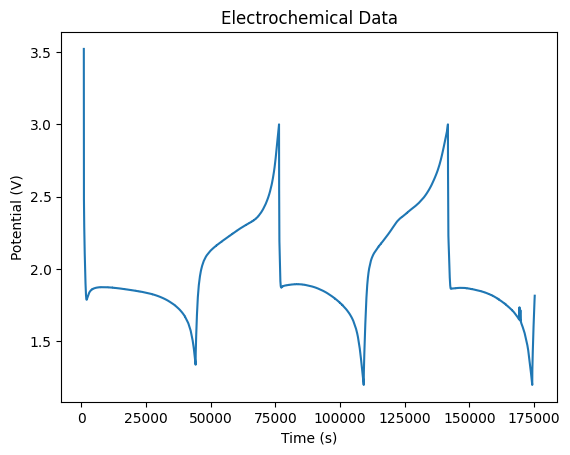

Applied current: 0.17739999294281006
Mass of active material: 1.06 mg


In [7]:
ec_results = process_electrochemical_data(all_data, rate=sample_settings['Discharge_Rate'])

## 5. Generate SAXS Contour Plot

# Perform SAXS Background Correction

Subtracting SAXS background...


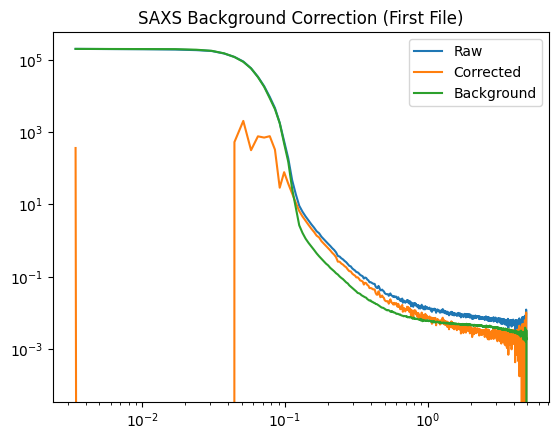

In [8]:

if all_data.get('Background_SAXS') is not None:
    print("Subtracting SAXS background...")
    corrected_saxs = subtract_background(all_data['SAXS'], all_data['Background_SAXS'])
    # Plot an example to verify
    import matplotlib.pyplot as plt
    plt.figure()
    idx = list(corrected_saxs.keys())[0]
    plt.plot(10 * all_data['SAXS'][idx].iloc[:,0], all_data['SAXS'][idx].iloc[:,1], label="Raw")
    plt.plot(10 * corrected_saxs[idx].iloc[:,0], corrected_saxs[idx].iloc[:,1], label="Corrected")
    plt.plot(10 * all_data['Background_SAXS'].iloc[:,0], all_data['Background_SAXS'].iloc[:,1], label="Background")
    plt.xscale('log')
    plt.yscale('log')
    plt.legend()
    plt.title("SAXS Background Correction (First File)")
    plt.show()
else:
    print("No SAXS background found to subtract.")
    corrected_saxs = all_data['SAXS']

Starting file: 3, Discharge file: 113, Last file: 195


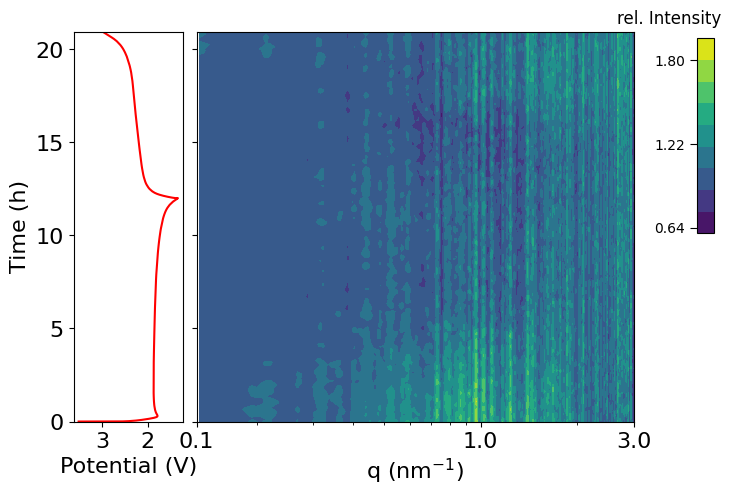

In [18]:
contourplot(
    starting_cycle=1, 
    final_cycle=1, 
    ec_results=ec_results,
    plot_type='saxs',
    data_normalization='relative',
    Normalization_file='discharge_file', # or starting_file
    data_dictionary=corrected_saxs, #all_data['SAXS'],
   # data_dictionary=all_data['SAXS'],    
    new_time_dict=all_data['TimeStamps_SAXS'],
    min_limit=sample_settings['SAXS_Min_Limit'],
    max_limit=sample_settings['SAXS_Max_Limit'],
    y_axis_mode='time',
    colorbar_position = 'side'
)

## 6. Generate WAXS Contour Plot

Subtracting WAXS background...


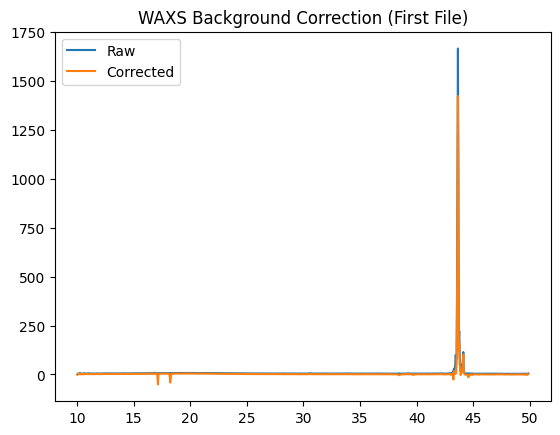

Empty cell corrected WAXS data stored as 'corrected_waxs' dataframe


In [19]:
# Perform WAXS Background Correction
if all_data.get('Background_WAXS') is not None:
    print("Subtracting WAXS background...")
    # Using target_X for alignment as per Operando-7
    corrected_waxs = subtract_background(all_data['WAXS'], all_data['Background_WAXS'], align_target_X=3.4)
    # Plot an example to verify
    import matplotlib.pyplot as plt
    import numpy as np
    plt.figure()
    idx = list(corrected_waxs.keys())[0]
    X_raw = 10 * all_data['WAXS'][idx].iloc[:,0]
    two_theta = 2 * np.degrees(np.arcsin((0.154 * X_raw) / (4 * np.pi)))
    plt.plot(two_theta, all_data['WAXS'][idx].iloc[:,1] * 1000, label="Raw")
    plt.plot(two_theta, corrected_waxs[idx].iloc[:,1] * 1000, label="Corrected")
    plt.legend()
    plt.title("WAXS Background Correction (First File)")
    plt.show()
    print("Empty cell corrected WAXS data stored as 'corrected_waxs' dataframe")
else:
    print("No WAXS background found to subtract.")
    corrected_waxs = all_data['WAXS']

Starting file: 3, Discharge file: 113, Last file: 361


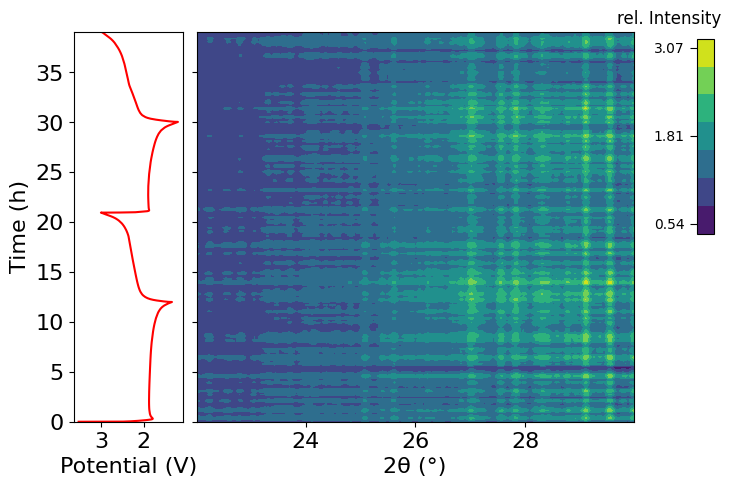

In [22]:
contourplot(
    starting_cycle=1, 
    final_cycle=2, 
    ec_results=ec_results,
    plot_type='waxs',
    data_normalization='relative',
    Normalization_file='starting_file', # or starting_file
    data_dictionary=corrected_waxs,
    new_time_dict=all_data['TimeStamps_WAXS'],
    min_limit=sample_settings['WAXS_Min_Limit'],
    max_limit=sample_settings['WAXS_Max_Limit'],
    y_axis_mode='time',
    colorbar_position = 'side'
)

## 4.5. WAXS Peak Masking (Optional)
Remove sharp artifact peaks (like cosmic rays or dead pixels) by selecting Q-range windows. The data in these windows will be masked and filled with a linear interpolation connecting the two boundaries.

In [ ]:
from classes_and_functions.preprocessing import create_masking_ui
from IPython.display import display

if 'corrected_waxs' in locals():
    base_waxs = corrected_waxs
else:
    base_waxs = all_data['WAXS']

waxs_dict_to_correct = {}
mask_ui = create_masking_ui(base_waxs, waxs_dict_to_correct)
display(mask_ui)

## 5. WAXS Baseline Correction (Optional)
This interactive tool lets you fit a baseline using `pybaselines` to the WAXS data. You can preview the fit on a selected reference file and then apply it to all WAXS files either uniformly or individually.

In [ ]:
from classes_and_functions.preprocessing import create_baseline_ui
from IPython.display import display

if 'waxs_dict_to_correct' not in locals() or not waxs_dict_to_correct:
    waxs_dict_to_correct = corrected_waxs if 'corrected_waxs' in locals() else all_data['WAXS']

waxs_baseline_corrected_dict = {}
baseline_ui = create_baseline_ui(waxs_dict_to_correct, waxs_baseline_corrected_dict)
display(baseline_ui)

# ---- COMBINED ELECTROCHEMISTRY + SAXS + WAXS PLOT ----

Starting file: 3, Discharge file: 113, Last file: 361


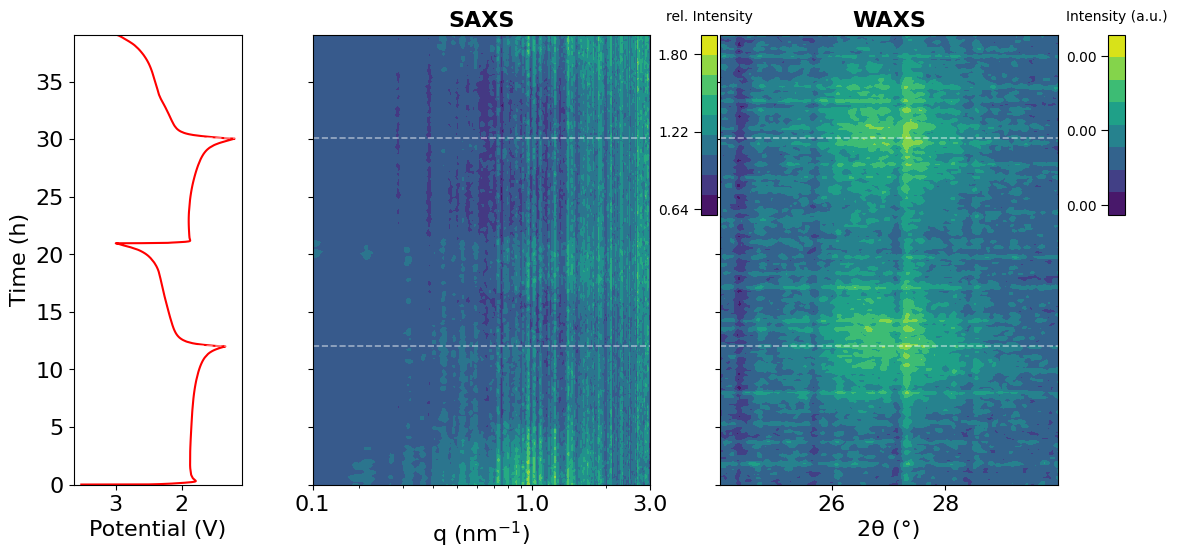

In [28]:
# This single plot shows the electrochemistry curve next to both SAXS and WAXS contour plots

# You can choose 'side' or 'bottom' for colorbar_position
combined_contourplot(
    starting_cycle=1, 
    final_cycle=2, 
    ec_results=ec_results,

    saxs_data_normalization='relative',
    waxs_data_normalization='absolute', # 'relative' or 'absolute'
    
    saxs_dict=corrected_saxs,
    waxs_dict=waxs_baseline_corrected_dict,#all_data['WAXS'],
    
    new_time_dict=all_data['TimeStamps_SAXS'],
    saxs_min_limit=sample_settings['SAXS_Min_Limit'],
    saxs_max_limit=sample_settings['SAXS_Max_Limit'],
    waxs_min_limit=24, 
    waxs_max_limit=30,
    Normalization_file_saxs='discharge_file', # Set your normalization file for SAXS
    Normalization_file_waxs='starting_file', # Set your normalization file for WAXS
    colorbar_position='side', # Options: 'side', 'bottom'
    inset_colorbar_inside=True,
    y_axis_mode='time', # 'time' or 'capacity'
    applied_current=ec_results['applied_current'], # Required if y_axis_mode='time'
    active_material_mass=ec_results['active_material_mass'], # Required if y_axis_mode='time'
    save_plot=False,
    discharge_files=ec_results.get('discharge_saxs_files', None)
)

## 7. Available Dataframes Summary
Here is a quick summary of the key dataframes and dictionaries generated during this analysis pipeline:

**1. `all_data` Dictionary:**
- `all_data['SAXS']`: A dictionary of all raw SAXS dataframes, indexed by file number.
- `all_data['WAXS']`: A dictionary of all raw WAXS dataframes, indexed by file number.
- `all_data['Electrochemical']`: A dataframe containing the raw BioLogic electrochemical data.
- `all_data['Time']`: A dictionary mapping elapsed time to file numbers.
- `all_data['Background_SAXS']`: The dataframe for the SAXS empty cell/background.
- `all_data['Background_WAXS']`: The dataframe for the WAXS empty cell/background.

**2. Processed Electrochemical Data:**
- `elec_df_2`: The processed and filtered electrochemical dataframe perfectly synced with the SAXS/WAXS timestamps. It includes calculated capacities and cycle numbers.

**3. Corrected Scattering Data:**
- `corrected_saxs`: A dictionary of SAXS dataframes after subtracting the empty cell background.
- `corrected_waxs`: A dictionary of WAXS dataframes after subtracting the empty cell background.
- `waxs_baseline_corrected_dict`: A dictionary of WAXS dataframes after applying the optional polynomial baseline correction and cropping (from Section 5).

**4. Settings Data:**
- `settings_df`: A dataframe containing all the sample settings loaded from `sample_settings.csv`.
- `sample_settings`: A pandas Series containing the specific settings for the currently selected sample (e.g., Data Path, Limits, etc.).

# Waterfall plots

## 6. Generate Waterfall Plots
Generate 3D and 2D waterfall plots for WAXS data.

In [ ]:
# Define starting and discharge files based on electrochemical data analysis above.
# We use a default starting_file = 1 and discharge_file as the first identified cycle change, if available.
starting_file = 1
if 'ec_results' in locals() and ec_results is not None and ec_results.get('Cycle_Changes_SAXS'):
    discharge_file = ec_results['Cycle_Changes_SAXS'][0] # usually the first index is the end of discharge
else:
    discharge_file = max(all_data['WAXS'].keys()) if 'all_data' in locals() and all_data.get('WAXS') else 100

last_file = max(all_data['WAXS'].keys()) if 'all_data' in locals() and all_data.get('WAXS') else discharge_file + 10

print(f"Generating Waterfall plots for WAXS from file {starting_file} to {last_file}...")

# 3D Waterfall Plot
plot_3d_waterfall(
    data_dictionary=waxs_baseline_corrected_dict,
    starting_file=starting_file,
    last_file=last_file,
    discharge_file=discharge_file,
    q_min=16.9, q_max=19.8,
    offset_increment=0.000002,
    save_plot=False
)

# 2D Waterfall Plot
plot_2d_waterfall(
    data_dictionary=waxs_baseline_corrected_dict,
    starting_file=starting_file,
    discharge_file=discharge_file,
    q_min=16.96, q_max=21.12,
    intensity_min=0, intensity_max=0.02,
    offset_increment=0.00001,
    highlight_file=discharge_file,
    save_plot=False
)


# Manual plots of SAXS and WAXS data 

In [ ]:
plot_selected_curves(
    data_dict=all_data['SAXS'], 
    file_numbers=[3,113,195,278,361], # Change this list to whichever files you want to inspect
    is_waxs=False, 
    q_min=0.13, 
    q_max=3.0
)


In [ ]:
plot_selected_curves(
    data_dict= waxs_baseline_corrected_dict, #all_data['WAXS'], 
    file_numbers=[3,113,195,278,361], # Change this list to whichever files you want to inspect
    is_waxs=True, 
    q_min=16, 
    q_max=24,
    apply_smoothing=True,   # <--- Turn on noise reduction
    smoothing_method= 'gaussian',
    #window_length=15,       # Optional: adjust how aggressive the smoothing is (must be odd)
    #polyorder=2 
    gaussian_sigma= 2.0
)


## 7. Peak Fitting & Crystallite Size (Scherrer)
Fit Lorentzian peaks to the WAXS data, calculate peak areas, and apply the Scherrer equation for crystallite size.

In [29]:
# Define the peaks you want to fit. You can provide multiple mean positions for multiple peaks (e.g., Li2S and Sulfur)
mean_positions = [1.85] # Add more positions if needed, e.g., [1.85, 2.3]
min_q = 1.75
max_q = 2.05

# We define the list of files to fit
file_numbers = list(range(starting_file, last_file + 1))

print("Fitting WAXS peaks... This might take a moment.")
# Note: we pass new_time_dict and applied_current/active_material_mass for capacity calculation if available
df_curves, df_scherrer = fit_waxs_peaks(
    data_dict= waxs_baseline_corrected_dict, #all_data['WAXS']
    file_numbers=file_numbers,
    mean_positions=mean_positions,
    min_x=min_q, max_x=max_q,
    wavelength=0.15406, K=0.9,
    new_time_dict=all_data.get('TimeStamps_SAXS'),
    applied_current=0.5, # Update with actual current if known, else ignore
    active_material_mass=2.0 # Update with actual mass if known, else ignore
)

display(df_curves.head())
display(df_scherrer.head())

# Display interactive plot to verify the fits visually
print("Use the slider below to verify the curve fits across your dataset:")
interactive_fit_viewer(
    data_dict=waxs_baseline_corrected_dict,
    df_curves=df_curves,
    file_numbers=file_numbers,
    mean_positions=mean_positions,
    min_x=min_q, max_x=max_q
)


NameError: name 'starting_file' is not defined

In [ ]:
#plot_peak_areas(df_curves, window_length=41, smoothing_method='savgol', polyorder=3)
#plot_peak_areas(df_curves, window_length=15, smoothing_method='gaussian', gaussian_sigma=5.0)
#plot_peak_areas(df_curves, window_length=25, smoothing_method='moving_average')

plot_peak_areas(df_curves, window_length=25, smoothing_method='moving_median', filter_error_threshold=0.1,
                starting_cycle=2, final_cycle=2, ec_results=ec_results)

# To plot Particle/Crystallite Size:
plot_peak_areas(df_scherrer, starting_cycle=1, final_cycle=5, ec_results=ec_results, filter_error_threshold=2,window_length=41, smoothing_method='savgol',polyorder=3)



## 8. SAXS Integrated Intensity & Invariants
Calculate the total integrated intensity, mean q, and invariant from the SAXS data.

In [ ]:
df_saxs = calculate_saxs_invariants(
    data_dict=all_data["SAXS"],
    file_numbers=list(all_data["SAXS"].keys()),
    q_range_intensity=(0.5, 3.0), # Change these for Integrated Intensity
    q_range_mean=(0.5, 3.0),      # Change these for Mean q
    q_range_invariant=(0.2, 4.0), # Full range for Invariant
    new_time_dict=all_data.get("TimeStamps_SAXS")
)
display(df_saxs.head())

In [ ]:
# Plot the results
plot_saxs_invariants(df_saxs, normalize=False, starting_cycle=1, final_cycle=3, 
                    ec_results=ec_results, plot_cycle_lines=True)

## 9. Combined SAXS, WAXS, and Electrochemistry Plot
This plot combines the electrochemical potential curve with the SAXS integrated intensity and the WAXS peak area, plotted against the specific capacity.

In [ ]:
# Combine SAXS, WAXS (Peak 1), and EC data into one plot
plot_combined_saxs_waxs_ec(
    starting_cycle=4, final_cycle=5,
    df_saxs=df_saxs,
    df_curves=df_curves,
    ec_results=ec_results,
    all_data=all_data,
    starting_file=starting_file,
    last_file=last_file,
    peak_col="Peak_1_Area",
    saxs_col="Integrated_Intensity"
)
